<center>
    <h1></h1>
    <h1><b>OCES 5303</b></h1>
    <h2>Extended Project</h2>
    <hr>
    <p>Jonas Mathisrud Sterud</p>
    <p>21335836</p>
</center>

<center>
    <h1></h1>
    <h3><i>Abstract</i></h3>
    <p>
    ...
    </p>
    <img src="./figures/cover.jpg" width="50%">
</center>

## Configuration

In [117]:
## Imports

import numpy as np
import pandas as pd
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import cv2
import pickle
import random
import os

from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer, SplineTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error, r2_score
from datetime import datetime

from torch import nn
from skorch import NeuralNetRegressor

## Configuration

seed = int(11111)
_ = random.seed(seed)
_ = np.random.seed(seed)
_ = torch.manual_seed(seed)
_ = torch.backends.cudnn.deterministic = True
_ = torch.backends.cudnn.benchmark = False

## Colors

RED = "#FF6200"
RED_TRANSPARENT = "#FF6200A7"
GREEN = "#00B755"
GREEN_TRANSPARENT = "#00B755A7"
BLUE = "#0048FF"
BLUE_TRANSPARENT = "#0048FFA7"
GREY = "#959595"
GREY_TRANSPARENT = "#959595A7"


<h1>The Data</h1>

<p>

</p>

In [2]:
"./data/train_images_pkl/20170514/eddy_centre.pkl".split("/")[-1].removesuffix(".pkl")

'eddy_centre'

In [ ]:
TRAIN_PNG_DIR = "./data/TRAIN_png/TRAIN_png"
TEST_PNG_DIR = "./data/TEST_png/TEST_png"
LABELS_TRAIN_DIR = "./data/LABELS_TRAIN/train"
TRAIN_IMAGES_PKL_DIR = "./data/train_images_pkl"
TEST_IMAGES_PKL_DIR = "./data/test_images_pkl"

# Load PKLs

def load_pkl(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as dirs:
        for dir in dirs:
            date = datetime.strptime(dir.path.split("/")[-1], "%Y%m%d")

            out[date] = {}
            with os.scandir(dir) as files:
                for file in files:
                    if file.is_file():
                        name = file.path.split("/")[-1].removesuffix(".pkl")
                        if (name == "eddy_centre"): # Only Eddy centres for now
                            with open(file.path, "rb") as rb_file:
                                try:
                                    data = pickle.load(rb_file)
                                    out[date][name] = data
                                except Exception as e:
                                    print(e)
    
    return out

# Load labels
def load_labels(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            date = datetime.strptime(file.path.split("_")[-1].removesuffix(".csv"), "%Y%m%d")
            labels = pd.read_csv(file.path, header=None)

            out[date] = labels

    return out

# Load PNGs

def load_pngs(directory: str) -> pd.DataFrame:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            if file.is_file:
                (category, date, number) = file.path.split("/")[-1].removesuffix(".png").split("_")
                category = category
                date = datetime.strptime(date, "%Y%m%d")
                number = int(number)

                if out.get(category) == None:
                    out[category] = {}

                if out[category].get(date) == None:
                    out[category][date] = {}

                out[category][date][number] = cv2.imread(file.path, cv2.IMREAD_GRAYSCALE)

    for category in out.keys():
        for date in out[category].keys():
            out[category][date] = list(map(lambda kv: kv[1], sorted(out[category][date].items())))

    return pd.DataFrame(out)

# Load

df_png_train = load_pngs(TRAIN_PNG_DIR)
df_png_test = load_pngs(TEST_PNG_DIR)
train_pkl_mapping = load_pkl(TRAIN_IMAGES_PKL_DIR)

labels_mapping = load_labels(LABELS_TRAIN_DIR)

# Format Eddy centres, labels

#df_eddy_centre = pd.DataFrame(map(lambda k: (k, train_pkl_mapping[k]["eddy_centre"]), train_pkl_mapping.keys())).set_index(0).rename(columns={ 1: "EDDY_CENTRE"})
df_eddy_centre = pd.DataFrame(map(lambda kv: (kv[0], kv[1]["eddy_centre"]), train_pkl_mapping.items())).set_index(0).rename(columns={ 1 : "EDDY_CENTRE"})
df_labels = pd.DataFrame(map(lambda kv: (kv[0], kv[1].values), labels_mapping.items())).set_index(0).rename(columns={ 1: "TRAIN_LABELS"})

# Combine
df_train = pd.concat([df_png_train, df_eddy_centre, df_labels], axis=1, sort=False)
#df_train = pd.concat([df_train, df_labels], axis=1, sort=False)

df_train.head(1)
#labels_mapping

,EDDY,SST,SLA,CHLA,EDDY_CENTRE,TRAIN_LABELS
2017-05-22,"[[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0,...","[[[178, 181, 189, 198, 206, 212, 217, 217, 217...","[[[0, 31, 90, 153, 196, 207, 189, 166], [26, 4...","[[[0, 0, 0, 0, 0, 0, 0, 255, 255, 255, 255, 25...","[[nan, nan], [nan, nan], [nan, nan], [nan, nan...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


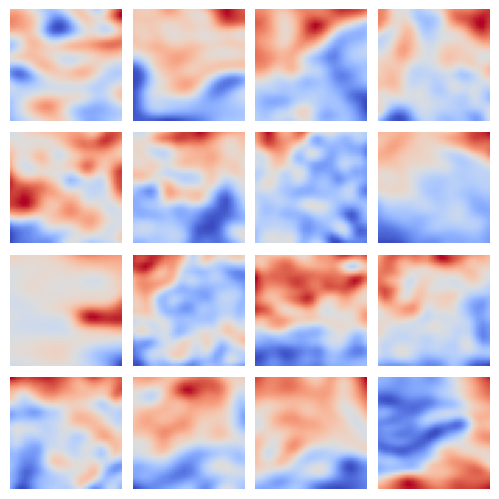

In [299]:
fig, axs = plt.subplots(4, 4)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

eddy_images = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 1, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SST"])))))

for i, ax in enumerate(axs.flat):
    # Select image
    image = eddy_images[i]
    
    # Image
    ax.imshow(image, cmap="coolwarm")
    ax.axis('off')


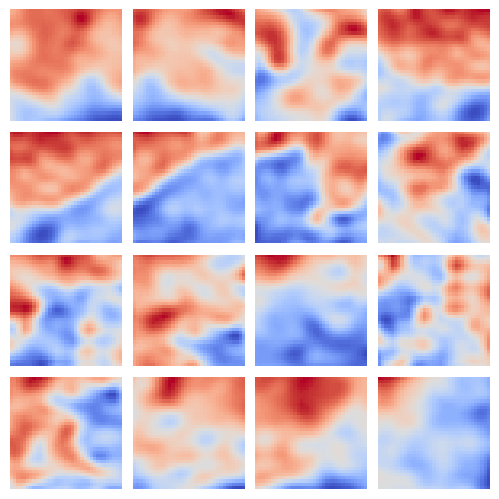

In [300]:
fig, axs = plt.subplots(4, 4)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

eddy_images = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 0, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SST"])))))

for i, ax in enumerate(axs.flat):
    # Select image
    image = eddy_images[i]
    
    # Image
    ax.imshow(image, cmap="coolwarm")
    ax.axis('off')


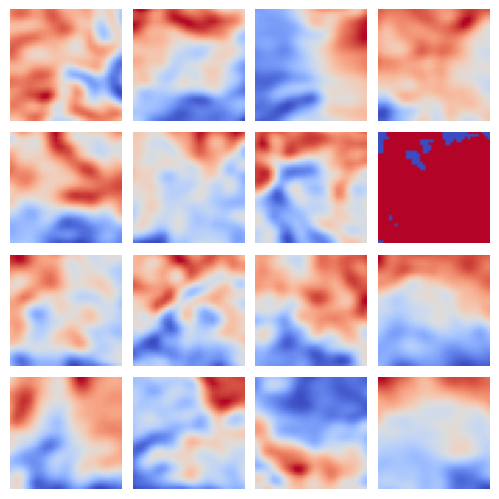

In [302]:
fig, axs = plt.subplots(4, 4)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

eddy_images = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == 2, map(lambda iv: (df_train.iloc[0]["TRAIN_LABELS"][0][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SST"])))))

for i, ax in enumerate(axs.flat):
    # Select image
    image = eddy_images[i]
    
    # Image
    ax.imshow(image, cmap="coolwarm")
    ax.axis('off')


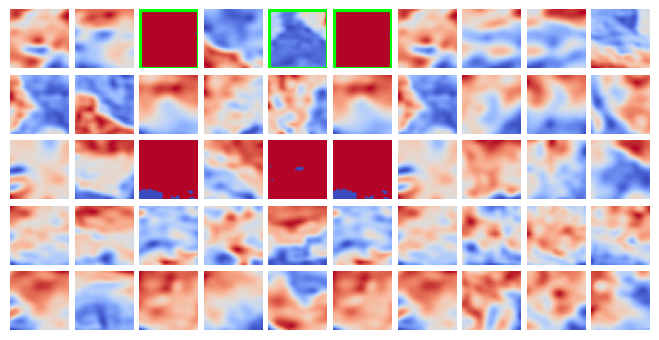

In [268]:
fig, axs = plt.subplots(5, 10)
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.1, hspace=-.7)

random_i = [random.randint(0, len(df_train) - 1) for _ in range(0, 5)]
random_j = [random.randint(0, 50) for _ in range(0, 10)]

for i, axi in enumerate(axs):
    for j, axj in enumerate(axi):
        # Select image
        image = df_train.iloc[random_i[i]]["SST"][random_j[j]]

        # Border?
        if df_train.iloc[random_i[i]]["TRAIN_LABELS"][0][random_j[j]] == 1:
            rect = mpl.patches.Rectangle((0, 0), width=len(image), height=len(image[0]), fc="none", ec="lime", lw=3)
            axj.add_patch(rect)
        elif df_train.iloc[random_i[i]]["TRAIN_LABELS"][0][random_j[j]] == 2:
            rect = mpl.patches.Rectangle((0, 0), width=len(image), height=len(image[0]), fc="none", ec="blue", lw=3)
            axj.add_patch(rect)
        
        # Image
        axj.imshow(image, cmap="coolwarm")
        axj.axis('off')
        
        # # Text
        # if i == 0: axj.set_title(f"Nr. {j + 1}", fontsize=10)
        # if j == 0: axj.text(-0.2, 0.5, df_train.iloc[i + i_offset].name.strftime("%d.%m.%Y"), transform=axj.transAxes, va='center', ha='right')

<h1>Training, Validation, and Test Datasets</h1>

<p>
...
</p>

<h1>Exploratory Data Analysis</h1>

<p>
...
</p>

<h1>Model</h1>

<p>
...
</p>

<h1>Metrics</h1>

<p>
...
</p>

<h1>Conclusion</h1>

<p>
...
</p>

<h1>References</h1>

<p>[1] Authors. Title. Name. (Year). <a href="https://www.example.com" target="_blank">https://www.example.com/</a> (Accessed online: date)</p>

<p>[1] Dennis G Wilson, Mercator Hackathon, Simon van Gennip, and svangennip. Ocean Eddy Identification. Kaggle. (2022). <a href="https://www.kaggle.com/competitions/mercatorocean" target="_blank">https://www.kaggle.com/competitions/mercatorocean/data</a> (Accessed online: 20.04.2026)</p>